In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimpy import skim
import statsmodels.api as sm
from sklearn.model_selection import train_test_split as tts
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score
from sklearn.metrics import roc_curve, auc ,recall_score, f1_score,precision_recall_curve, average_precision_score
import warnings
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

In [4]:
data = pd.read_csv("data_stress.csv")
data.head()

,snoring range,respiration rate,body temperature,limb movement,blood oxygen,eye movement,hours of sleep,heart rate,Stress Levels
0,93.80,25.680,91.840,16.600,89.840,99.60,1.840,74.20,3
1,91.64,25.104,91.552,15.880,89.552,98.88,1.552,72.76,3
2,60.00,20.000,96.000,10.000,95.000,85.00,7.000,60.00,1
3,85.76,23.536,90.768,13.920,88.768,96.92,0.768,68.84,3
4,48.12,17.248,97.872,6.496,96.248,72.48,8.248,53.12,0


In [5]:
skim(data)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 630    │ │ float64     │ 8     │                                                          │
│ │ Number of columns │ 9      │ │ int64       │ 1     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column            ┃ NA  ┃ NA %               ┃ mean  ┃ sd    ┃ p0 ┃ p25   ┃ p50   ┃ p75   ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ snoring range     │   0 │                  0 │  71.6 │ 19.37 │ 45 │  52.5 │    70 │ 91.25 │   100 │ ▇▅▃▃▃▇ │  │
│ │ respiration rate  │   0 │                  0 │ 21.92 │ 4.336 │ 16 │  18.5 │ 21.02 │ 25.06 │ 48.56 │  ▇▅▂   │  │
│ │ body temperature  │  16 │ 2.5396825396825395 │ 93.47 │ 6.833 │ 85 │ 90.58 │ 93.08 │  95.6 │ 166.2 │   ▇    │  │
│ │ limb movement     │  12 │ 1.9047619047619047 │ 11.95 │ 5.001 │  4 │ 8.516 │ 11.05 │ 15.95 │  46.8 │  ▇▆▁   │  │
│ │ blood oxygen      │   4 │ 0.6349206349206349 │ 91.05 │ 4.892 │ 82 │ 88.48 │    91 │ 94.27 │ 154.3 │   ▇▃   │  │
│ │ eye movement      │  18 │  2.857142857142857 │ 88.96 │ 13.48 │ 60 │ 81.23 │ 90.08 │ 98.89 │ 185.4 │  ▃▇▂   │  │
│ │ hours of sleep    │  11 │  1.746031746031746 │ 3.836 │ 3.341 │  0 │ 0.472 │ 3.608 │ 6.592 │ 20.22 │  ▇▅▃   │  │
│ │ heart rate        │  24 │ 3.8095238095238093 │  64.9 │ 11.26 │ 50 │ 56.21 │ 62.54 │ 72.74 │ 158.7 │   ▇▅   │  │
│ │ Stress Levels     │   0 │                  0 │     2 │ 1.415 │  0 │     1 │     2 │     3 │     4 │ ▇▇ ▇▇▇ │  │
│ └───────────────────┴─────┴────────────────────┴───────┴───────┴────┴───────┴───────┴───────┴───────┴────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [6]:
data.columns = data.columns.str.strip()
data.columns = data.columns.str.replace(" ", "_")
data.columns

Index(['snoring_range', 'respiration_rate', 'body_temperature',
       'limb_movement', 'blood_oxygen', 'eye_movement', 'hours_of_sleep',
       'heart_rate', 'Stress_Levels'],
      dtype='object')

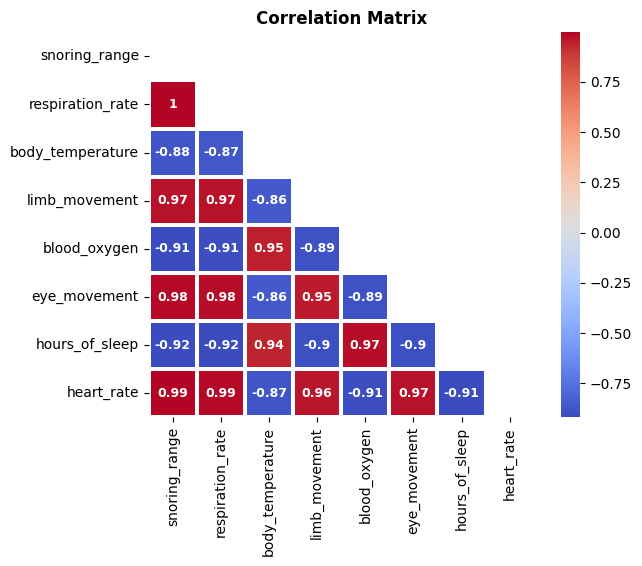

In [7]:
plt.style.use('default')
numerical_features = data.columns[:-1]
corr_matrix = data[numerical_features].corr(method = 'spearman')
mask = np.triu(np.ones_like(corr_matrix, dtype = bool))

fig,ax = plt.subplots(figsize = (7,5))
sns.heatmap(corr_matrix, annot = True, 
            annot_kws = {'fontsize':9, 'fontweight':'bold'}, 
            square = True, 
            mask = mask, 
            cmap = 'coolwarm',
            linewidths = 1.5,
            ax = ax)
ax.set_title("Correlation Matrix", fontsize = 12, fontweight = 'bold', color = 'black')
fig.show()

In [8]:
feature = data.drop(columns = 'Stress_Levels')
target = data['Stress_Levels']

SEED = 123

feature_train, feature_test, target_train, target_test = tts(feature, 
                                       target, 
                                       test_size = 0.2, 
                                       random_state = SEED, 
                                       shuffle = True)

In [9]:
model = XGBClassifier(random_state = SEED, n_jobs = -1)

In [10]:
model.fit(feature_train, target_train)
pred_train = model.predict(feature_train)
pred_test = model.predict(feature_test)
score_train = accuracy_score(target_train, pred_train)
score_test = accuracy_score(target_test, pred_test)

print("TEST ACCURACY SCORE : ",score_test)
print("SCORE TRAIN : ",score_train)

TEST ACCURACY SCORE :  0.9920634920634921
SCORE TRAIN :  1.0


In [11]:
joblib.dump(model,"XGB_model.pkl")

['XGB_model.pkl']

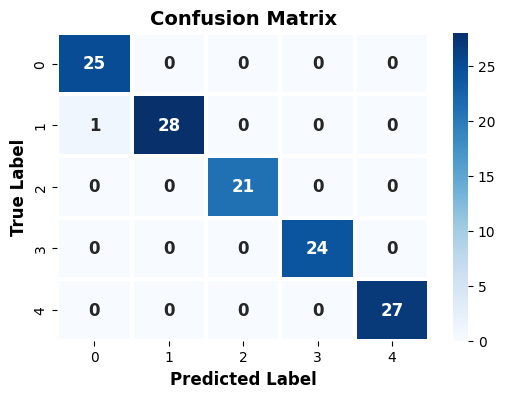

In [12]:
# Generate predictions
target_pred = model.predict(feature_test)

# Compute confusion matrix
cm = confusion_matrix(target_test, target_pred)

# Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", linewidths=1.5, annot_kws={"size": 12, "weight": "bold"})
plt.xlabel("Predicted Label", fontsize=12, fontweight="bold")
plt.ylabel("True Label", fontsize=12, fontweight="bold")
plt.title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.show()


In [13]:
# Predictions
target_pred = model.predict(feature_test)

# Accuracy Score
accuracy = accuracy_score(target_test, target_pred)
precision = precision_score(target_test, target_pred, average='weighted')  # Use 'macro' or 'micro' based on preference
recall = recall_score(target_test, target_pred, average='weighted')
f1 = f1_score(target_test, target_pred, average='weighted')

# Print the scores
print(f"Accuracy Score: {accuracy:.4f}")
print(f"Precision Score: {precision:.4f}")
print(f"Recall Score: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Accuracy Score: 0.9921
Precision Score: 0.9924
Recall Score: 0.9921
F1 Score: 0.9921


In [14]:
# Predictions
target_pred = model.predict(feature_test)

# Generate Classification Report
report = classification_report(target_test, target_pred)

# Print Report
print("Classification Report:\n")
print(report)


Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        25
           1       1.00      0.97      0.98        29
           2       1.00      1.00      1.00        21
           3       1.00      1.00      1.00        24
           4       1.00      1.00      1.00        27

    accuracy                           0.99       126
   macro avg       0.99      0.99      0.99       126
weighted avg       0.99      0.99      0.99       126



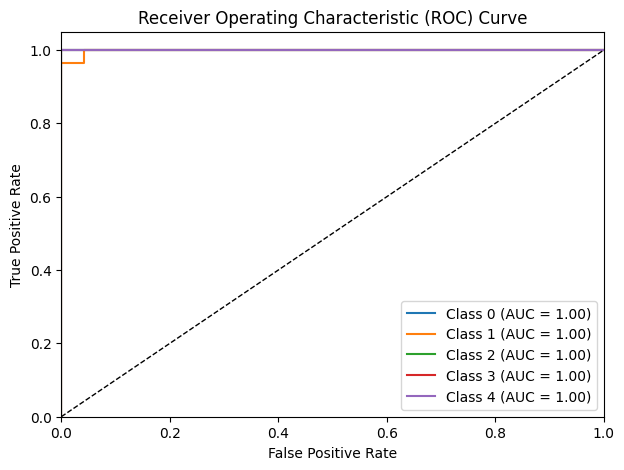

In [15]:
# Get predicted probabilities
target_probs = model.predict_proba(feature_test)

# Plot ROC Curve for each class
plt.figure(figsize=(7, 5))

for i in range(len(np.unique(target_test))):  
    fpr, tpr, _ = roc_curve(target_test == i, target_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)  # Random classifier line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


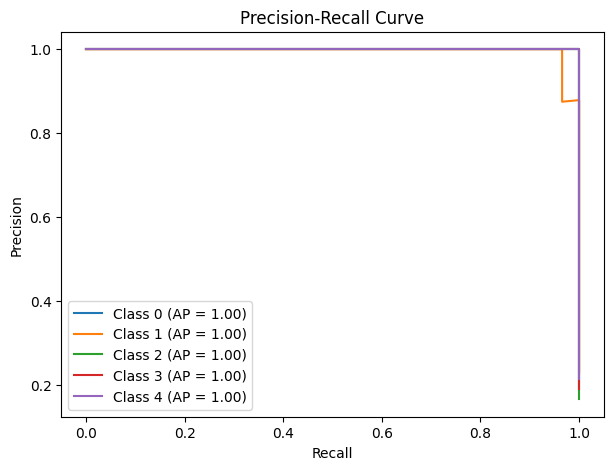

In [16]:
# Plot PR Curve for each class
plt.figure(figsize=(7, 5))

for i in range(len(np.unique(target_test))):
    precision, recall, _ = precision_recall_curve(target_test == i, target_probs[:, i])
    ap_score = average_precision_score(target_test == i, target_probs[:, i])
    plt.plot(recall, precision, label=f'Class {i} (AP = {ap_score:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.show()
